# 04 — Feature Engineering
## Urban Mobility Intelligence Platform | Chicago TNC 2024

### Research Context
This notebook implements **Section III-D: Feature Engineering** of the paper.

Feature engineering is the most critical stage of the pipeline.
The goal is to transform raw trip records into rich, informative representations
that capture temporal patterns, spatial structure, and demand dynamics
relevant to all three modeling tasks.

### Three output datasets
Each task receives a purpose-built feature set:

| Task | Target | Dataset |
|---|---|---|
| Task 1: Surge Classification | is_surge (binary) | df_classification.parquet |
| Task 2: Fare Regression | log(trip_total) | df_regression.parquet |
| Task 3: Demand Forecasting | hourly_trip_count | df_timeseries.parquet |

### Feature categories
1. **Cleaning** — remove invalid rows, flag out-of-city trips
2. **Temporal features** — cyclical encoding, peak flags, holiday indicators
3. **Spatial features** — zone embeddings, distance to city center
4. **Demand features** — lag features, rolling statistics per zone
5. **Trip features** — duration, distance, shared trip indicators
6. **Target engineering** — surge flag, log fare transformation

### Output
Saved to `data/parquet/` — three Parquet files ready for modeling

In [7]:
import os
import numpy as np
import pandas as pd
from google.cloud import bigquery
import matplotlib.pyplot as plt
import seaborn as sns

os.environ["GOOGLE_APPLICATION_CREDENTIALS"] = r"E:\Projects\ML\Transport taxi chicago\gcp_credentials.json"

client      = bigquery.Client(project="urban-mobility-intel")
FINAL_TABLE = "urban-mobility-intel.chicago_tnc.trips_final"

# output paths
PARQUET_DIR     = r"E:\Projects\ML\Transport taxi chicago\data\parquet"
CLF_PATH        = os.path.join(PARQUET_DIR, "df_classification.parquet")
REG_PATH        = os.path.join(PARQUET_DIR, "df_regression.parquet")
TS_PATH         = os.path.join(PARQUET_DIR, "df_timeseries.parquet")

os.makedirs(PARQUET_DIR, exist_ok=True)

print(f"Connected: {client.project}")
print(f"Output dir: {PARQUET_DIR}")

Connected: urban-mobility-intel
Output dir: E:\Projects\ML\Transport taxi chicago\data\parquet


## 1. Data Cleaning
Remove invalid rows and flag out-of-city trips.
This implements the cleaning decisions documented in Section III-C.
All cleaning happens in BigQuery before pulling data to Python.

In [2]:
# pull cleaned data from bigquery
# all filtering happens server-side — only clean rows come to python

clean_query = f"""
SELECT
    trip_start_timestamp,
    trip_end_timestamp,
    trip_seconds,
    trip_miles,
    pickup_community_area,
    dropoff_community_area,
    trip_total,
    shared_trip_authorized,
    shared_trip_match,
    trips_pooled,

    -- flag out of city trips instead of dropping
    CASE WHEN pickup_community_area = 0 
         OR dropoff_community_area = 0
         THEN 1 ELSE 0 END AS is_out_of_city

FROM `{FINAL_TABLE}`

WHERE
    -- drop null financial rows
    trip_total IS NOT NULL
    AND trip_total > 0

    -- drop null or zero duration
    AND trip_seconds IS NOT NULL
    AND trip_seconds > 0

    -- drop zero distance
    AND trip_miles > 0

    -- drop fare anomalies (extreme outliers beyond 99.9th percentile)
    AND trip_total < 500
    AND trip_miles < 150
    AND trip_seconds < 21600
"""

print("Pulling cleaned data from BigQuery...")
df = client.query(clean_query).to_dataframe(
    create_bqstorage_client=True,
    progress_bar_type="tqdm"
)

print(f"Rows after cleaning : {len(df):,}")
print(f"Columns             : {list(df.columns)}")
print(f"Memory usage        : {df.memory_usage(deep=True).sum() / 1024**3:.2f} GB")

Pulling cleaned data from BigQuery...
Job ID a49bead9-5d34-4fcd-b89c-15bf84d64406 successfully executed: 100%|██████████|
Downloading: 100%|██████████|
Rows after cleaning : 18,229,241
Columns             : ['trip_start_timestamp', 'trip_end_timestamp', 'trip_seconds', 'trip_miles', 'pickup_community_area', 'dropoff_community_area', 'trip_total', 'shared_trip_authorized', 'shared_trip_match', 'trips_pooled', 'is_out_of_city']
Memory usage        : 1.36 GB


## 2. Temporal Feature Engineering
Extract and encode time-based features from trip_start_timestamp.

Cyclical encoding (sin/cos) is used for hour and day of week to preserve
the circular nature of time — hour 23 and hour 0 are adjacent, not distant.
Using raw integer encoding would incorrectly treat them as far apart.

Peak flags capture known demand surge windows identified in EDA Section 6.
Holiday flag captures US public holidays where demand patterns deviate
significantly from normal weekday/weekend behavior.

In [3]:
# temporal feature engineering

# US public holidays 2024
us_holidays_2024 = [
    "2024-01-01",  # New Year's Day
    "2024-01-15",  # MLK Day
    "2024-02-19",  # Presidents Day
    "2024-05-27",  # Memorial Day
    "2024-06-19",  # Juneteenth
    "2024-07-04",  # Independence Day
    "2024-09-02",  # Labor Day
    "2024-11-11",  # Veterans Day
    "2024-11-28",  # Thanksgiving
    "2024-12-25",  # Christmas
]
holidays = pd.to_datetime(us_holidays_2024).date

# extract base temporal components
df['hour']      = df['trip_start_timestamp'].dt.hour
df['dow']       = df['trip_start_timestamp'].dt.dayofweek  # 0=Mon, 6=Sun
df['month']     = df['trip_start_timestamp'].dt.month
df['day_of_year'] = df['trip_start_timestamp'].dt.dayofyear

# cyclical encoding — preserves circular nature of time
df['hour_sin']  = np.sin(2 * np.pi * df['hour'] / 24)
df['hour_cos']  = np.cos(2 * np.pi * df['hour'] / 24)
df['dow_sin']   = np.sin(2 * np.pi * df['dow'] / 7)
df['dow_cos']   = np.cos(2 * np.pi * df['dow'] / 7)
df['month_sin'] = np.sin(2 * np.pi * df['month'] / 12)
df['month_cos'] = np.cos(2 * np.pi * df['month'] / 12)

# peak period flags from eda findings
df['is_weekend']      = (df['dow'] >= 5).astype(int)
df['is_morning_peak'] = df['hour'].between(7, 9).astype(int)
df['is_evening_peak'] = df['hour'].between(16, 19).astype(int)
df['is_late_night']   = (df['hour'] >= 22) | (df['hour'] <= 3)
df['is_late_night']   = df['is_late_night'].astype(int)

# holiday flag
df['is_holiday'] = df['trip_start_timestamp'].dt.date.isin(holidays).astype(int)

print("Temporal features added.")
print(f"Holiday trips: {df['is_holiday'].sum():,}")
print(f"Weekend trips: {df['is_weekend'].sum():,}")
print(f"Morning peak : {df['is_morning_peak'].sum():,}")
print(f"Evening peak : {df['is_evening_peak'].sum():,}")
print(f"Late night   : {df['is_late_night'].sum():,}")

Temporal features added.
Holiday trips: 498,187
Weekend trips: 5,181,028
Morning peak : 2,372,203
Evening peak : 4,386,143
Late night   : 3,144,261


## 3. Spatial Feature Engineering
Engineer location-based features from community area identifiers.

Airport zones (56=Midway, 76=O'Hare) are flagged explicitly as they represent
a distinct trip population identified in the bimodal distance distribution (EDA Section 5).
These zones command significantly higher fares and lower surge rates than urban zones.

Zone frequency encoding captures the demand level of each pickup zone —
high-frequency zones have more driver supply and different pricing dynamics
than low-frequency zones.

In [4]:
# spatial feature engineering

# airport zone flags — identified in eda as distinct trip population
df['is_airport'] = df['pickup_community_area'].isin([56, 76]).astype(int)

# zone frequency encoding
# captures demand level of each pickup zone
zone_counts = df['pickup_community_area'].value_counts()
df['pickup_zone_freq'] = df['pickup_community_area'].map(zone_counts)
df['dropoff_zone_freq'] = df['dropoff_community_area'].map(zone_counts)

# normalize zone frequency to 0-1 range
df['pickup_zone_freq_norm']  = df['pickup_zone_freq']  / df['pickup_zone_freq'].max()
df['dropoff_zone_freq_norm'] = df['dropoff_zone_freq'] / df['dropoff_zone_freq'].max()

# same zone flag — pickup and dropoff in same community area
df['is_same_zone'] = (
    df['pickup_community_area'] == df['dropoff_community_area']
).astype(int)

# downtown zone flag — zones 8, 32, 28, 6, 7 are city center from eda
downtown_zones = [8, 32, 28, 6, 7, 24]
df['is_downtown_pickup']  = df['pickup_community_area'].isin(downtown_zones).astype(int)
df['is_downtown_dropoff'] = df['dropoff_community_area'].isin(downtown_zones).astype(int)

print("Spatial features added.")
print(f"Airport trips        : {df['is_airport'].sum():,}")
print(f"Same zone trips      : {df['is_same_zone'].sum():,}")
print(f"Downtown pickup      : {df['is_downtown_pickup'].sum():,}")
print(f"Downtown dropoff     : {df['is_downtown_dropoff'].sum():,}")
print(f"Unique pickup zones  : {df['pickup_community_area'].nunique()}")
print(f"Unique dropoff zones : {df['dropoff_community_area'].nunique()}")

Spatial features added.
Airport trips        : 1,157,179
Same zone trips      : 2,293,294
Downtown pickup      : 7,854,792
Downtown dropoff     : 7,847,315
Unique pickup zones  : 78
Unique dropoff zones : 78


## 4. Trip Feature Engineering
Engineer features from raw trip measurements.

Log transformation of distance and duration compresses the right-skewed
distributions identified in EDA, improving model performance on
gradient boosting algorithms.

Speed feature captures average trip speed — a proxy for traffic conditions
and route efficiency that is not captured by distance or duration alone.

In [5]:
# trip feature engineering

# log transformations — compresses right skew identified in eda
df['log_trip_seconds'] = np.log1p(df['trip_seconds'])
df['log_trip_miles']   = np.log1p(df['trip_miles'])

# average speed — proxy for traffic conditions
# miles per hour = (miles / seconds) * 3600
df['avg_speed_mph'] = (df['trip_miles'] / df['trip_seconds']) * 3600

# cap extreme speeds — above 100mph is likely GPS error
df['avg_speed_mph'] = df['avg_speed_mph'].clip(upper=100)

# trip distance buckets — captures the bimodal distribution from eda
df['trip_distance_bucket'] = pd.cut(
    df['trip_miles'],
    bins=[0, 2, 5, 10, 20, 150],
    labels=[1, 2, 3, 4, 5]
).astype(int)

# shared trip features
df['is_pooled'] = (df['trips_pooled'] > 1).astype(int)
df['shared_trip_authorized'] = df['shared_trip_authorized'].astype(int)
df['shared_trip_match']      = df['shared_trip_match'].astype(int)

# trip duration buckets
df['trip_duration_bucket'] = pd.cut(
    df['trip_seconds'],
    bins=[0, 300, 600, 1200, 2400, 21600],
    labels=[1, 2, 3, 4, 5]
).astype(int)

print("Trip features added.")
print(f"Avg speed stats:")
print(df['avg_speed_mph'].describe().round(2).to_string())
print(f"\nDistance bucket distribution:")
print(df['trip_distance_bucket'].value_counts().sort_index().to_string())

Trip features added.
Avg speed stats:
count    18229241.00
mean           19.50
std            10.28
min             0.00
25%            12.18
50%            16.52
75%            24.23
max           100.00

Distance bucket distribution:
trip_distance_bucket
1    4587305
2    5531425
3    3690978
4    3316821
5    1102712


## 4.1 Trip Feature Distributions
Visual check of engineered trip features.

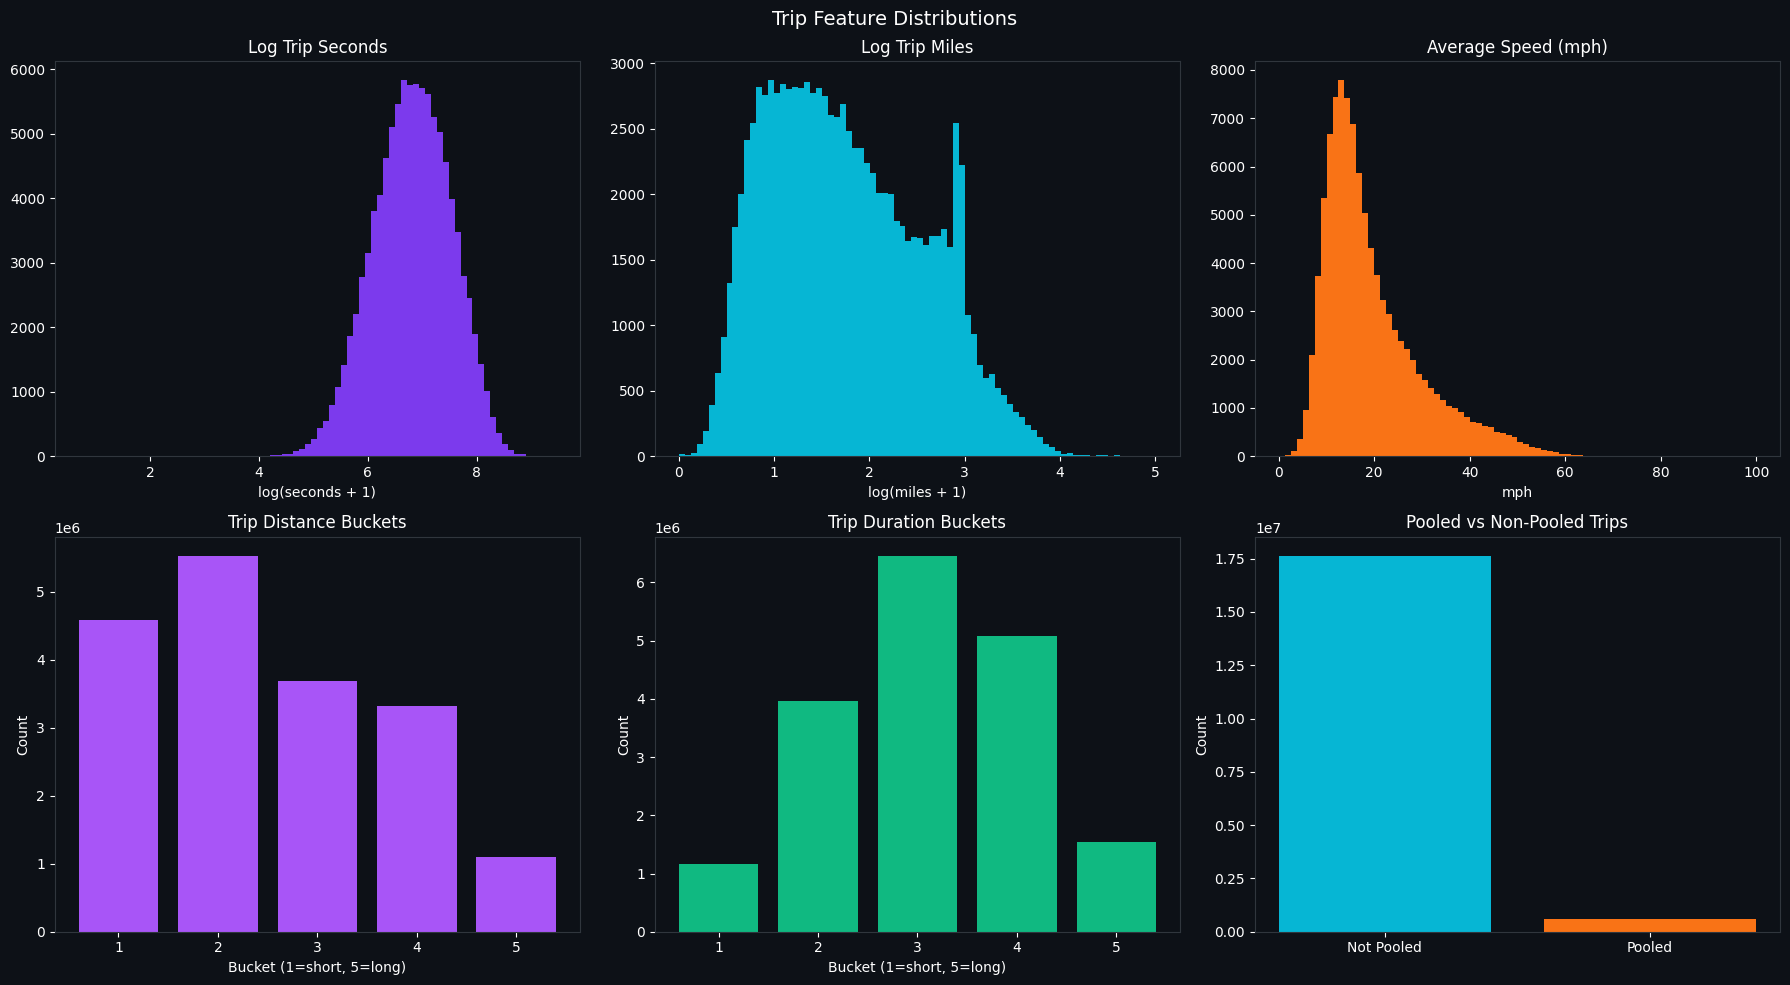

In [8]:
# trip feature distributions

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
fig.patch.set_facecolor('#0d1117')
for ax in axes.flatten():
    ax.set_facecolor('#0d1117')
    ax.tick_params(colors='white')
    ax.xaxis.label.set_color('white')
    ax.yaxis.label.set_color('white')
    ax.title.set_color('white')
    for spine in ax.spines.values():
        spine.set_edgecolor('#30363d')

sample = df.sample(100000, random_state=42)

# log trip seconds
axes[0,0].hist(sample['log_trip_seconds'], bins=80, color='#7c3aed', edgecolor='none')
axes[0,0].set_title("Log Trip Seconds")
axes[0,0].set_xlabel("log(seconds + 1)")

# log trip miles
axes[0,1].hist(sample['log_trip_miles'], bins=80, color='#06b6d4', edgecolor='none')
axes[0,1].set_title("Log Trip Miles")
axes[0,1].set_xlabel("log(miles + 1)")

# avg speed
axes[0,2].hist(sample['avg_speed_mph'], bins=80, color='#f97316', edgecolor='none')
axes[0,2].set_title("Average Speed (mph)")
axes[0,2].set_xlabel("mph")

# distance buckets
bucket_counts = df['trip_distance_bucket'].value_counts().sort_index()
axes[1,0].bar(bucket_counts.index, bucket_counts.values, color='#a855f7', edgecolor='none')
axes[1,0].set_title("Trip Distance Buckets")
axes[1,0].set_xlabel("Bucket (1=short, 5=long)")
axes[1,0].set_ylabel("Count")

# duration buckets
dur_counts = df['trip_duration_bucket'].value_counts().sort_index()
axes[1,1].bar(dur_counts.index, dur_counts.values, color='#10b981', edgecolor='none')
axes[1,1].set_title("Trip Duration Buckets")
axes[1,1].set_xlabel("Bucket (1=short, 5=long)")
axes[1,1].set_ylabel("Count")

# pooled vs not pooled
pooled_counts = df['is_pooled'].value_counts()
axes[1,2].bar(['Not Pooled', 'Pooled'], pooled_counts.values, 
              color=['#06b6d4', '#f97316'], edgecolor='none')
axes[1,2].set_title("Pooled vs Non-Pooled Trips")
axes[1,2].set_ylabel("Count")

plt.suptitle("Trip Feature Distributions", color='white', fontsize=14)
plt.tight_layout()
plt.savefig(r"E:\Projects\ML\Transport taxi chicago\data\plots\06_trip_features.png",
            dpi=150, bbox_inches='tight', facecolor='#0d1117')
plt.show()

## 5. Target Engineering
Engineer the two prediction targets:

**Task 1 — Surge classification target:**
A trip is surge if its fare exceeds 1.5x the median fare for that specific
hour and pickup zone combination. This definition controls for both
temporal and spatial pricing context, avoiding misclassification of
legitimately expensive airport or late-night trips as surge.

**Task 2 — Fare regression target:**
Log transformation of trip_total normalizes the right-skewed fare
distribution identified in EDA, satisfying the approximate normality
assumption that improves gradient boosting regression performance.

In [9]:
# target engineering

# --- task 1: surge classification target ---

# compute median fare per pickup zone per hour
zone_hour_median = (
    df[df['is_out_of_city'] == 0]  # use only in-city trips for median
    .groupby(['pickup_community_area', 'hour'])['trip_total']
    .median()
    .reset_index()
    .rename(columns={'trip_total': 'median_fare'})
)

# merge median back to main dataframe
df = df.merge(zone_hour_median, on=['pickup_community_area', 'hour'], how='left')

# define surge: trip_total > 1.5x median fare for that zone and hour
df['is_surge'] = (df['trip_total'] > 1.5 * df['median_fare']).astype(int)

# drop median_fare column — only needed for surge calculation
df.drop(columns=['median_fare'], inplace=True)

# --- task 2: fare regression target ---
df['log_trip_total'] = np.log1p(df['trip_total'])

# --- verify targets ---
surge_rate = df['is_surge'].mean()
print("Target Engineering Summary")
print(f"  Surge rate          : {surge_rate:.2%}")
print(f"  Non-surge trips     : {(df['is_surge']==0).sum():,}")
print(f"  Surge trips         : {(df['is_surge']==1).sum():,}")
print(f"  scale_pos_weight    : {(1-surge_rate)/surge_rate:.2f}")
print(f"\n  log_trip_total stats:")
print(df['log_trip_total'].describe().round(3).to_string())

Target Engineering Summary
  Surge rate          : 21.19%
  Non-surge trips     : 14,365,611
  Surge trips         : 3,863,630
  scale_pos_weight    : 3.72

  log_trip_total stats:
count    1.822924e+07
mean     2.998000e+00
std      5.890000e-01
min      3.900000e-02
25%      2.589000e+00
50%      2.931000e+00
75%      3.358000e+00
max      6.216000e+00


## 6. Demand Features — Zone-Level Lag and Rolling Statistics
Engineer temporal demand features that capture recent trip activity
per zone. These features are critical for:

- **Surge classification:** High recent demand in a zone predicts surge
- **Fare regression:** Demand pressure affects pricing
- **Time series:** Lag features are the primary predictors for forecasting

Lag features capture what happened in the same zone at previous time steps.
Rolling statistics capture the trend over recent windows.

Note: These features are computed on the full dataset ordered by time —
correct temporal ordering is essential to prevent data leakage.
Lag features only look backward, never forward.

In [ ]:
# zone-level lag and rolling demand features
# sort by zone and time first — critical for correct lag computation

print("Sorting data by zone and timestamp")
df = df.sort_values(['pickup_community_area', 'trip_start_timestamp']).reset_index(drop=True)

# create hour bucket for aggregation
df['hour_bucket'] = df['trip_start_timestamp'].dt.floor('h')

# compute hourly trip count per zone
print("Computing hourly zone demand")
zone_hourly = (
    df.groupby(['pickup_community_area', 'hour_bucket'])
    .size()
    .reset_index(name='zone_hour_count')
    .sort_values(['pickup_community_area', 'hour_bucket'])
)

# lag features per zone
# lag_1h  — demand one hour ago
# lag_24h — demand same hour yesterday
# lag_168h — demand same hour last week
print("Computing lag features")
zone_hourly['lag_1h']   = zone_hourly.groupby('pickup_community_area')['zone_hour_count'].shift(1)
zone_hourly['lag_24h']  = zone_hourly.groupby('pickup_community_area')['zone_hour_count'].shift(24)
zone_hourly['lag_168h'] = zone_hourly.groupby('pickup_community_area')['zone_hour_count'].shift(168)

# rolling mean features per zone
# roll_3h  — avg demand over past 3 hours
# roll_24h — avg demand over past 24 hours
print("Computing rolling features...")
zone_hourly['roll_3h']  = (
    zone_hourly.groupby('pickup_community_area')['zone_hour_count']
    .transform(lambda x: x.shift(1).rolling(3, min_periods=1).mean())
)
zone_hourly['roll_24h'] = (
    zone_hourly.groupby('pickup_community_area')['zone_hour_count']
    .transform(lambda x: x.shift(1).rolling(24, min_periods=1).mean())
)

# merge lag features back to main dataframe
print("Merging demand features")
df = df.merge(
    zone_hourly[['pickup_community_area', 'hour_bucket',
                 'zone_hour_count', 'lag_1h', 'lag_24h',
                 'lag_168h', 'roll_3h', 'roll_24h']],
    on=['pickup_community_area', 'hour_bucket'],
    how='left'
)

print(f"Demand features added.")
print(f"Null lag_1h  : {df['lag_1h'].isna().sum():,}  (first hour per zone — expected)")
print(f"Null lag_24h : {df['lag_24h'].isna().sum():,}")
print(f"Null lag_168h: {df['lag_168h'].isna().sum():,}")
print(f"\nZone hour count stats:")
print(df['zone_hour_count'].describe().round(2).to_string())

Sorting data by zone and timestamp...
Computing hourly zone demand...
Computing lag features...
Computing rolling features...
Merging demand features...
Demand features added.
Null lag_1h  : 3,599  (first hour per zone — expected)
Null lag_24h : 50,019
Null lag_168h: 350,651

Zone hour count stats:
count    18229241.00
mean          142.46
std           135.63
min             1.00
25%            25.00
50%            99.00
75%           232.00
max           847.00


## 7. Additional Engineered Features
Two high-value features added before saving:

**demand_vs_lag_ratio:** Captures whether current zone demand is higher or lower
than the same hour yesterday — a relative demand pressure signal stronger than
absolute counts alone.

**zone_surge_rate_rolling:** Rolling 24-hour surge rate per zone — captures
historical surge tendency of each zone. Purely historical, no leakage risk.
This is expected to be among the top features in the surge classifier.

In [11]:
# additional engineered features

# demand vs lag ratio — relative demand pressure
# how much busier is this zone right now vs same hour yesterday?
df['demand_vs_lag_ratio'] = (
    df['zone_hour_count'] / df['lag_24h'].replace(0, np.nan)
).fillna(1.0)  # fill with 1.0 where lag is null (no change assumed)

# cap extreme ratios — prevents outliers from dominating
df['demand_vs_lag_ratio'] = df['demand_vs_lag_ratio'].clip(upper=10)

# zone surge rate rolling — historical surge tendency per zone
# compute hourly surge rate per zone first
print("Computing zone surge rate history...")
zone_surge_hourly = (
    df.groupby(['pickup_community_area', 'hour_bucket'])['is_surge']
    .mean()
    .reset_index(name='zone_hour_surge_rate')
    .sort_values(['pickup_community_area', 'hour_bucket'])
)

# rolling 24h surge rate per zone — shift(1) ensures no leakage
zone_surge_hourly['zone_surge_rate_24h'] = (
    zone_surge_hourly.groupby('pickup_community_area')['zone_hour_surge_rate']
    .transform(lambda x: x.shift(1).rolling(24, min_periods=1).mean())
)

# merge back
df = df.merge(
    zone_surge_hourly[['pickup_community_area', 'hour_bucket', 'zone_surge_rate_24h']],
    on=['pickup_community_area', 'hour_bucket'],
    how='left'
)

# fill nulls with overall surge rate
overall_surge_rate = df['is_surge'].mean()
df['zone_surge_rate_24h'] = df['zone_surge_rate_24h'].fillna(overall_surge_rate)

print("Additional features added.")
print(f"demand_vs_lag_ratio stats:")
print(df['demand_vs_lag_ratio'].describe().round(3).to_string())
print(f"\nzone_surge_rate_24h stats:")
print(df['zone_surge_rate_24h'].describe().round(3).to_string())

Computing zone surge rate history...
Additional features added.
demand_vs_lag_ratio stats:
count    1.822924e+07
mean     1.217000e+00
std      7.070000e-01
min      5.000000e-03
25%      8.790000e-01
50%      1.062000e+00
75%      1.333000e+00
max      1.000000e+01

zone_surge_rate_24h stats:
count    1.822924e+07
mean     2.120000e-01
std      9.400000e-02
min      0.000000e+00
25%      1.720000e-01
50%      2.200000e-01
75%      2.690000e-01
max      8.760000e-01


## 7.1 Interaction & Ratio Features
Two final features before saving:

**trip_count_vs_zone_avg:** Normalizes current demand against each zone's
historical baseline — captures unusually busy periods relative to
zone-specific norms rather than absolute counts.

**is_rush_hour_downtown:** Interaction term capturing the high-surge
combination of peak hours and downtown location — identified in EDA
as the strongest spatial-temporal surge predictor.

In [12]:
# interaction and ratio features

# zone average trip count across all hours
zone_avg_count = (
    df.groupby('pickup_community_area')['zone_hour_count']
    .mean()
    .reset_index(name='zone_avg_count')
)

df = df.merge(zone_avg_count, on='pickup_community_area', how='left')

# how busy is this zone right now vs its normal baseline
df['trip_count_vs_zone_avg'] = (
    df['zone_hour_count'] / df['zone_avg_count'].replace(0, np.nan)
).fillna(1.0).clip(upper=10)

# drop helper column
df.drop(columns=['zone_avg_count'], inplace=True)

# rush hour downtown interaction
df['is_rush_hour_downtown'] = (
    (df['is_morning_peak'] | df['is_evening_peak']) &
    df['is_downtown_pickup']
).astype(int)

print("Interaction features added.")
print(f"trip_count_vs_zone_avg stats:")
print(df['trip_count_vs_zone_avg'].describe().round(3).to_string())
print(f"\nis_rush_hour_downtown trips: {df['is_rush_hour_downtown'].sum():,}")
print(f"Pct of total             : {df['is_rush_hour_downtown'].mean():.2%}")

Interaction features added.
trip_count_vs_zone_avg stats:
count    1.822924e+07
mean     1.000000e+00
std      4.280000e-01
min      7.000000e-03
25%      7.240000e-01
50%      9.730000e-01
75%      1.249000e+00
max      1.000000e+01

is_rush_hour_downtown trips: 2,901,497
Pct of total             : 15.92%


In [13]:
# final feature inventory
exclude = ['trip_start_timestamp', 'trip_end_timestamp', 
           'hour_bucket', 'trip_total', 'is_surge', 'log_trip_total']

feature_cols = [c for c in df.columns if c not in exclude]
print(f"Total features engineered: {len(feature_cols)}")
print("\nFull feature list:")
for i, col in enumerate(feature_cols, 1):
    print(f"  {i:2}. {col}")

Total features engineered: 47

Full feature list:
   1. trip_seconds
   2. trip_miles
   3. pickup_community_area
   4. dropoff_community_area
   5. shared_trip_authorized
   6. shared_trip_match
   7. trips_pooled
   8. is_out_of_city
   9. hour
  10. dow
  11. month
  12. day_of_year
  13. hour_sin
  14. hour_cos
  15. dow_sin
  16. dow_cos
  17. month_sin
  18. month_cos
  19. is_weekend
  20. is_morning_peak
  21. is_evening_peak
  22. is_late_night
  23. is_holiday
  24. is_airport
  25. pickup_zone_freq
  26. dropoff_zone_freq
  27. pickup_zone_freq_norm
  28. dropoff_zone_freq_norm
  29. is_same_zone
  30. is_downtown_pickup
  31. is_downtown_dropoff
  32. log_trip_seconds
  33. log_trip_miles
  34. avg_speed_mph
  35. trip_distance_bucket
  36. is_pooled
  37. trip_duration_bucket
  38. zone_hour_count
  39. lag_1h
  40. lag_24h
  41. lag_168h
  42. roll_3h
  43. roll_24h
  44. demand_vs_lag_ratio
  45. zone_surge_rate_24h
  46. trip_count_vs_zone_avg
  47. is_rush_hour_downtow

## 8. Save Feature Sets to Parquet

Three purpose-built datasets saved locally:
- `df_classification.parquet` — surge prediction, 47 features + is_surge target
- `df_regression.parquet`     — fare prediction, 47 features + log_trip_total target  
- `df_timeseries.parquet`     — hourly zone demand, aggregated structure

Parquet format chosen over CSV for:
- 6-8x compression vs CSV
- Preserves dtypes — no re-parsing on load
- Columnar storage — fast column-wise reads during model training

In [14]:
# define feature columns
exclude_cols = ['trip_start_timestamp', 'trip_end_timestamp',
                'hour_bucket', 'trip_total', 'is_surge', 'log_trip_total']

feature_cols = [c for c in df.columns if c not in exclude_cols]

# --- classification dataset ---
clf_cols = feature_cols + ['is_surge']
df_clf = df[clf_cols].copy()

# fill lag nulls with zone median
for col in ['lag_1h', 'lag_24h', 'lag_168h', 'roll_3h', 'roll_24h']:
    df_clf[col] = df_clf.groupby('pickup_community_area')[col].transform(
        lambda x: x.fillna(x.median())
    )

df_clf.to_parquet(CLF_PATH, index=False)
print(f"Classification dataset saved: {df_clf.shape}")
print(f"  Surge rate: {df_clf['is_surge'].mean():.2%}")
del df_clf

# --- regression dataset ---
reg_cols = feature_cols + ['trip_total', 'log_trip_total']
df_reg = df[reg_cols].copy()

for col in ['lag_1h', 'lag_24h', 'lag_168h', 'roll_3h', 'roll_24h']:
    df_reg[col] = df_reg.groupby('pickup_community_area')[col].transform(
        lambda x: x.fillna(x.median())
    )

df_reg.to_parquet(REG_PATH, index=False)
print(f"\nRegression dataset saved: {df_reg.shape}")
print(f"  Avg fare: ${df_reg['trip_total'].mean():.2f}")
del df_reg

# --- time series dataset ---
ts_cols = ['pickup_community_area', 'hour_bucket', 'zone_hour_count',
           'lag_1h', 'lag_24h', 'lag_168h', 'roll_3h', 'roll_24h',
           'hour', 'dow', 'month', 'day_of_year',
           'hour_sin', 'hour_cos', 'dow_sin', 'dow_cos',
           'month_sin', 'month_cos', 'is_weekend',
           'is_morning_peak', 'is_evening_peak', 'is_late_night',
           'is_holiday', 'is_downtown_pickup', 'is_airport',
           'demand_vs_lag_ratio', 'trip_count_vs_zone_avg']

df_ts = (
    df[ts_cols]
    .drop_duplicates(subset=['pickup_community_area', 'hour_bucket'])
    .sort_values(['pickup_community_area', 'hour_bucket'])
    .reset_index(drop=True)
)

for col in ['lag_1h', 'lag_24h', 'lag_168h', 'roll_3h', 'roll_24h']:
    df_ts[col] = df_ts.groupby('pickup_community_area')[col].transform(
        lambda x: x.fillna(x.median())
    )

df_ts.to_parquet(TS_PATH, index=False)
print(f"\nTime series dataset saved: {df_ts.shape}")
print(f"  Zones: {df_ts['pickup_community_area'].nunique()}")
print(f"  Hours: {df_ts['hour_bucket'].nunique()}")

print("\nAll datasets saved successfully.")
print(f"  {CLF_PATH}")
print(f"  {REG_PATH}")
print(f"  {TS_PATH}")

Classification dataset saved: (18229241, 48)
  Surge rate: 21.19%

Regression dataset saved: (18229241, 49)
  Avg fare: $23.20

Time series dataset saved: (654568, 27)
  Zones: 78
  Hours: 8783

All datasets saved successfully.
  E:\Projects\ML\Transport taxi chicago\data\parquet\df_classification.parquet
  E:\Projects\ML\Transport taxi chicago\data\parquet\df_regression.parquet
  E:\Projects\ML\Transport taxi chicago\data\parquet\df_timeseries.parquet


In [15]:
# verify parquet files on disk
import os

files = {
    'classification': CLF_PATH,
    'regression'    : REG_PATH,
    'timeseries'    : TS_PATH
}

print("Parquet file verification")
for name, path in files.items():
    size_mb = os.path.getsize(path) / (1024**2)
    df_check = pd.read_parquet(path, columns=[pd.read_parquet(path, columns=None).columns[0]])
    print(f"  {name:20} {size_mb:8.1f} MB   exists: {os.path.exists(path)}")

print("\nFeature engineering complete. Proceed to 05_classification.ipynb")

Parquet file verification
  classification          485.9 MB   exists: True
  regression              546.0 MB   exists: True
  timeseries                8.7 MB   exists: True

Feature engineering complete. Proceed to 05_classification.ipynb
